<a href="https://colab.research.google.com/github/erin-carroll/chess-isofit/blob/main/tutorials/train_plsr_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this notebook we will walk through training and deploying a simple partial least squares regression (PLSR) model to predict some continuous variable (e.g., leaf mass per area (LMA)) from extracted reflectance data. We wil use data from the 2018 campaign. The trait data are LMA values from [ ]. The spectral data are extracted from the updated 2018 surface reflectance retrievals (cite) using the crown polygons published from the 2018 campaign (cite). The extraction script is at (cite). This example is meant to provide a general example of preparing CHESS spectral data for model training, training a model, and deploying that model on the mosaic. It is not mean to be a tutorial in PLSR methods and the model trained here is not optimized.

The general steps are:
1. Prepare the reference data
2. Split the reference data into training and validation chunks  
3. Train a model
4. Deploy the model

In [2]:
# import s3fs
import pandas as pd
import xarray as xr
import numpy as np
import scipy
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [7]:
# replace this with s3 fps once up
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
# Load the extracted spectral data.
# These data include the site number, which we will use to join to the trait data, and the row/column and x/y coordinate of the extracted pixel. Pixels were extracted from the individual flightlines, not the mosaic, so the row and column correspond to the flightline map space.
# In the shade column, 1=sunlit and 0=shaded. The shade model was generated based on the geometry between the sun angle, ground surface, and sensor at the time of flight (cite). It is one conservative shade estimate, others could substituted.
# The remaining columns are the reflectance (rfl_band_*) and reflectance uncertainty (unc_band_*) data (one column ber band).

fp = '/content/drive/Shareddrives/MEL - Active/Projects/Projects_ErinCarroll/internships/JPL 2025/CHESS_workshop_data/site_extraction_spectra_2018.csv' # replace with s3 fp once up
df = pd.read_csv(fp)

df

,site_number,fid,row,col,x_utm,y_utm,shade,rfl_band_1,rfl_band_2,rfl_band_3,...,unc_band_417,unc_band_418,unc_band_419,unc_band_420,unc_band_421,unc_band_422,unc_band_423,unc_band_424,unc_band_425,unc_band_426
0,56.0,NIS01_20180612_175319,287.0,51.0,330986.390127,4.310048e+06,1.0,-0.01,-0.01,-0.01,...,3.207672,0.040933,0.041055,0.041216,0.041414,0.041645,0.041913,0.042218,0.019073,0.020141
1,56.0,NIS01_20180612_175319,287.0,52.0,330987.519570,4.310048e+06,1.0,-0.01,-0.01,-0.01,...,2.741531,0.034984,0.035089,0.035226,0.035395,0.035593,0.035823,0.036082,0.016299,0.017213
2,56.0,NIS01_20180612_175319,288.0,51.0,330986.040796,4.310047e+06,1.0,-0.01,-0.01,-0.01,...,3.423230,0.043683,0.043813,0.043985,0.044197,0.044444,0.044730,0.045055,0.020356,0.021496
3,56.0,NIS01_20180612_175319,288.0,52.0,330987.030727,4.310047e+06,1.0,-0.01,-0.01,-0.01,...,3.410080,0.043515,0.043645,0.043816,0.044027,0.044273,0.044558,0.044882,0.020274,0.021410
4,56.0,NIS01_20180613_154908,10552.0,554.0,330987.124509,4.310048e+06,1.0,-0.01,-0.01,-0.01,...,0.726340,0.009269,0.009296,0.009333,0.009378,0.009430,0.009491,0.009560,0.004315,0.004557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16149,41.0,NIS01_20180626_171026,879.0,5854.0,330798.753286,4.309677e+06,1.0,-0.01,-0.01,-0.01,...,0.052307,0.054083,0.056048,0.058183,0.060469,0.062890,0.065431,0.068078,0.054314,0.057950
16150,41.0,NIS01_20180626_171026,879.0,5855.0,330799.658656,4.309676e+06,1.0,-0.01,-0.01,-0.01,...,1.774277,0.055324,0.055312,0.055345,0.055417,0.055526,0.055677,0.055865,0.022886,0.024177
16151,41.0,NIS01_20180626_171026,880.0,5853.0,330798.128243,4.309675e+06,1.0,-0.01,-0.01,-0.01,...,1.965472,0.061286,0.061272,0.061309,0.061389,0.061510,0.061676,0.061885,0.025364,0.026795
16152,41.0,NIS01_20180626_171026,880.0,5854.0,330798.883392,4.309676e+06,1.0,-0.01,-0.01,-0.01,...,2.086536,0.065061,0.065046,0.065085,0.065170,0.065299,0.065475,0.065696,0.026919,0.028438


In [8]:
# Load the trait data and join it to the spectral data.
# This LMA data only covers a subset of sites, so we will just use those for this example.

fp = '/content/drive/Shareddrives/MEL - Active/Projects/Projects_ErinCarroll/internships/JPL 2025/CHESS_workshop_data/lma_site_samples.csv' #  replace with call from ESS-DIVE? or s3? Somewhere people can get it.
traits = pd.read_csv(fp)

# prepare a site number field to join the data on
traits['site_number'] = [float(x.split('-')[0]) for x in traits['SampleSiteCode']]

df = df.merge(traits[['site_number', 'LMA_gm2']], on='site_number', how='left')

df

,site_number,fid,row,col,x_utm,y_utm,shade,rfl_band_1,rfl_band_2,rfl_band_3,...,unc_band_418,unc_band_419,unc_band_420,unc_band_421,unc_band_422,unc_band_423,unc_band_424,unc_band_425,unc_band_426,LMA_gm2
0,56.0,NIS01_20180612_175319,287.0,51.0,330986.390127,4.310048e+06,1.0,-0.01,-0.01,-0.01,...,0.040933,0.041055,0.041216,0.041414,0.041645,0.041913,0.042218,0.019073,0.020141,80.1
1,56.0,NIS01_20180612_175319,287.0,52.0,330987.519570,4.310048e+06,1.0,-0.01,-0.01,-0.01,...,0.034984,0.035089,0.035226,0.035395,0.035593,0.035823,0.036082,0.016299,0.017213,80.1
2,56.0,NIS01_20180612_175319,288.0,51.0,330986.040796,4.310047e+06,1.0,-0.01,-0.01,-0.01,...,0.043683,0.043813,0.043985,0.044197,0.044444,0.044730,0.045055,0.020356,0.021496,80.1
3,56.0,NIS01_20180612_175319,288.0,52.0,330987.030727,4.310047e+06,1.0,-0.01,-0.01,-0.01,...,0.043515,0.043645,0.043816,0.044027,0.044273,0.044558,0.044882,0.020274,0.021410,80.1
4,56.0,NIS01_20180613_154908,10552.0,554.0,330987.124509,4.310048e+06,1.0,-0.01,-0.01,-0.01,...,0.009269,0.009296,0.009333,0.009378,0.009430,0.009491,0.009560,0.004315,0.004557,80.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16149,41.0,NIS01_20180626_171026,879.0,5854.0,330798.753286,4.309677e+06,1.0,-0.01,-0.01,-0.01,...,0.054083,0.056048,0.058183,0.060469,0.062890,0.065431,0.068078,0.054314,0.057950,364.3
16150,41.0,NIS01_20180626_171026,879.0,5855.0,330799.658656,4.309676e+06,1.0,-0.01,-0.01,-0.01,...,0.055324,0.055312,0.055345,0.055417,0.055526,0.055677,0.055865,0.022886,0.024177,364.3
16151,41.0,NIS01_20180626_171026,880.0,5853.0,330798.128243,4.309675e+06,1.0,-0.01,-0.01,-0.01,...,0.061286,0.061272,0.061309,0.061389,0.061510,0.061676,0.061885,0.025364,0.026795,364.3
16152,41.0,NIS01_20180626_171026,880.0,5854.0,330798.883392,4.309676e+06,1.0,-0.01,-0.01,-0.01,...,0.065061,0.065046,0.065085,0.065170,0.065299,0.065475,0.065696,0.026919,0.028438,364.3


In [9]:
# Prepare the reference data.

# drop the uncertainty data since we won't use it in this PLSR. It is a very useful input in other model architectures, and we encourge folks to use it!
df = df.loc[:, ~df.columns.str.startswith('unc')]

# drop the reflectance bands which were excluded from the inversion window for the reflectance retrievals due to strong atmospheric water absortion
rfl_cols = [x for x in df.columns if x.startswith('rfl')]
bad_bands = np.array([True if np.sum(df[x])<0 else False for x in rfl_cols])
df = df.drop(columns=np.array(rfl_cols)[bad_bands].tolist())
rfl_cols = [x for x in df.columns if x.startswith('rfl')]

# filter the df to complete examples
df = df.loc[~df.LMA_gm2.isna(), :]

# remove shaded pixels
df = df.loc[df.shade!=0, :]

df

,site_number,fid,row,col,x_utm,y_utm,shade,rfl_band_5,rfl_band_6,rfl_band_7,...,rfl_band_405,rfl_band_406,rfl_band_407,rfl_band_408,rfl_band_409,rfl_band_410,rfl_band_411,rfl_band_412,rfl_band_413,LMA_gm2
0,56.0,NIS01_20180612_175319,287.0,51.0,330986.390127,4.310048e+06,1.0,0.024431,0.024240,0.027381,...,0.074433,0.073066,0.074395,0.071572,0.069863,0.067372,0.068307,0.066978,0.065656,80.1
1,56.0,NIS01_20180612_175319,287.0,52.0,330987.519570,4.310048e+06,1.0,0.024319,0.022298,0.024015,...,0.075803,0.073385,0.072022,0.070179,0.067642,0.066428,0.068413,0.066548,0.066334,80.1
2,56.0,NIS01_20180612_175319,288.0,51.0,330986.040796,4.310047e+06,1.0,0.021563,0.022677,0.023232,...,0.072665,0.073563,0.072142,0.070418,0.069214,0.066058,0.065409,0.064598,0.066377,80.1
3,56.0,NIS01_20180612_175319,288.0,52.0,330987.030727,4.310047e+06,1.0,0.026497,0.027923,0.029257,...,0.089922,0.088010,0.089439,0.088263,0.083422,0.080667,0.085585,0.078551,0.081172,80.1
4,56.0,NIS01_20180613_154908,10552.0,554.0,330987.124509,4.310048e+06,1.0,0.018909,0.017769,0.020175,...,0.016238,0.016553,0.020941,0.014788,0.014526,0.013802,0.015421,0.015517,0.015927,80.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16149,41.0,NIS01_20180626_171026,879.0,5854.0,330798.753286,4.309677e+06,1.0,0.057769,0.058408,0.059008,...,0.255919,0.253984,0.257448,0.248056,0.246261,0.235753,0.250092,0.245566,0.248210,364.3
16150,41.0,NIS01_20180626_171026,879.0,5855.0,330799.658656,4.309676e+06,1.0,0.030079,0.029932,0.030882,...,0.132250,0.131997,0.132537,0.133458,0.129659,0.126665,0.129210,0.129200,0.126908,364.3
16151,41.0,NIS01_20180626_171026,880.0,5853.0,330798.128243,4.309675e+06,1.0,0.031131,0.032979,0.033162,...,0.139540,0.137497,0.140507,0.140010,0.136682,0.126927,0.134404,0.136036,0.131584,364.3
16152,41.0,NIS01_20180626_171026,880.0,5854.0,330798.883392,4.309676e+06,1.0,0.034896,0.035962,0.037147,...,0.155618,0.149750,0.155787,0.152158,0.151178,0.144199,0.153256,0.146007,0.145950,364.3


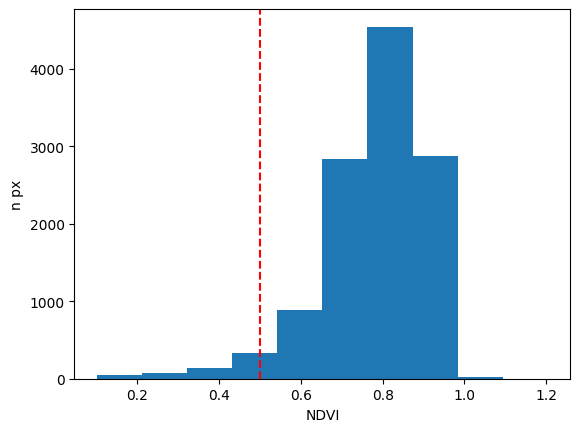

In [10]:
# use an NDVI filter to remove extracted pixels that do not represent vegetation
red = df['rfl_band_59']
nir = df['rfl_band_90']
ndvi = np.true_divide((nir-red),(nir+red))

# visualize the distribution of ndvi values in the extracted pixels
fig = plt.figure()
plt.hist(ndvi)
plt.xlabel('NDVI')
plt.ylabel('n px')
plt.axvline(x=0.5, linestyle='--', color='red')
plt.show()

# using an ndvi filter of 0.5 but this can be tuned
df = df.loc[ndvi>0.5, :]

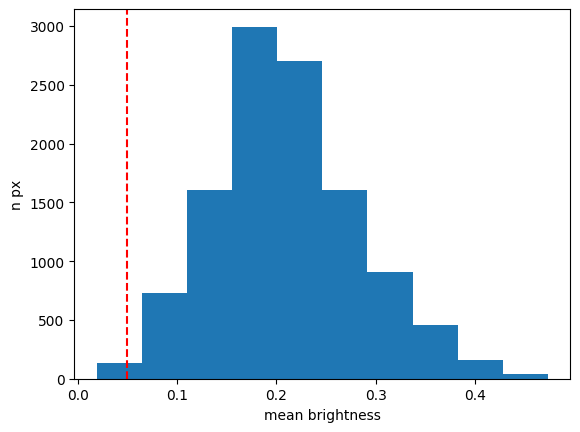

In [11]:
# check for any shaded pixels the shade mask might have missed using a brightness filter

# calculate a simple brightness index as the mean brightness across bands
b = df[rfl_cols].mean(axis=1)

# visualize the distribution of brightness values in the extracted pixels
fig = plt.figure()
plt.hist(b)
plt.xlabel('mean brightness')
plt.ylabel('n px')
plt.axvline(x=0.05, linestyle='--', color='red')
plt.show()

# remove pixels below some threshold
df = df.loc[b>0.05, :]

In [12]:
# Because the surface reflectance spectra are from flightlines observed wtih different relative geometries between the sensor and the sun (and therefore different amounts of shadow observed on non-lambertian surfaces), and are NOT brdf corrected, we can apply a brightness normalization to the remaining spectra.
rfl = df[rfl_cols].to_numpy()
brightness = np.sqrt(np.mean(np.power(rfl,2),axis=-1))
rfl = (rfl / brightness[:, np.newaxis])

print(rfl.shape)

# this leaves us with 11277 pixels and 365 brightness-normalized bands for model training and evaluation

(11277, 365)


In [13]:
# Split into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    rfl,
    df['LMA_gm2'],
    train_size=0.8,
    random_state=123
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9021, 365), (2256, 365), (9021,), (2256,))

In [14]:
# Fit the PLSR
pls = PLSRegression(n_components=10)
pls.fit(X_train, y_train)

# Deploy the trained model on the train and test feature spaces
y_train_pred = pls.predict(X_train).ravel()
y_test_pred = pls.predict(X_test).ravel()

y_train_pred.shape, y_test_pred.shape

((9021,), (2256,))

In [15]:
# Evaluate performance for the train and test sets

# Calculate the r2 between predicted and true values
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Calculate the rmse between predicted and true values
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f'train r^2: {train_r2:.3f}')
print(f'test r^2:  {test_r2:.3f}')
print(f'train rmse: {train_rmse:.3f}')
print(f'test rmse:  {test_rmse:.3f}')

train r^2: 0.769
test r^2:  0.757
train rmse: 70.901
test rmse:  72.482


train r^2: 0.769
test r^2:  0.757
train rmse: 70.901
test rmse:  72.482


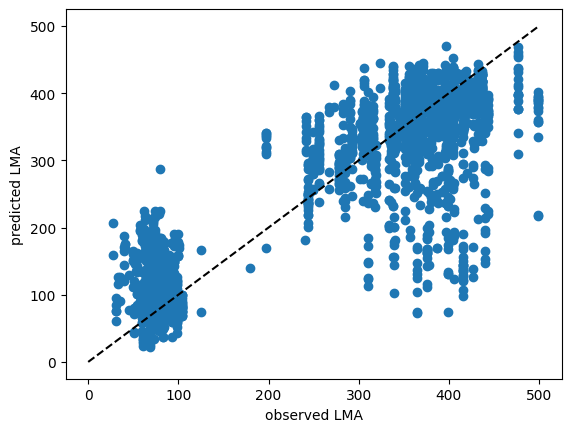

In [17]:
# testing again with the raw data

# Calculate the r2 between predicted and true values
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Calculate the rmse between predicted and true values
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f'train r^2: {train_r2:.3f}')
print(f'test r^2:  {test_r2:.3f}')
print(f'train rmse: {train_rmse:.3f}')
print(f'test rmse:  {test_rmse:.3f}')

# plot the test predicted vs. observed values
fig = plt.figure()
plt.scatter(y_test, y_test_pred)
plt.plot([0,500],[0,500], color='black', linestyle='--') # one-to-one line
plt.xlabel('observed LMA')
plt.ylabel('predicted LMA')
plt.show()

At this stage the model is not very good. There are two clumps of observed LMA values, and the model is largely over-predicting values in the true low LMA group and under-predicting values in the true high LMA group. It's even predicting negative LMA values for some samples. Further data cleaning and consideration of model architecture, parameters, or batching are warranted. But for the sake of this example, let's say we like this model and are ready to deploy it on the whole study area. You could do this by deploying on the entire mosaic (working per tile), or you could apply per flightline and mosaic the predictions according to your own preference. Here we will deploy the model on a single mosaic tile.

In [19]:
# Load a tile to deploy over

fp = '/content/drive/Shareddrives/MEL - Active/Projects/Projects_ErinCarroll/internships/JPL 2025/CHESS_workshop_data/CRBU_2025_mosaic_rfl_325000_4316000.nc' # replace with s3 to 2018 fp once up
ds = xr.open_dataset(fp)
rfl = ds['reflectance'].values
print(rfl.shape)

bands, ny, nx = rfl.shape
rfl = rfl.reshape(bands, ny * nx).T # reshape to pixel, band
print(rfl.shape)

(426, 1000, 1000)
(1000000, 426)


In [20]:
# apply the same processing to the tile data that we did to the model training data

# remove the strong atmospheric absorption bands
rfl = rfl[:,~bad_bands]

# brightness normalize
brightness = np.sqrt(np.mean(np.power(rfl,2),axis=-1))
rfl = (rfl / brightness[:, np.newaxis])

# exclude NA px
valid = np.isfinite(rfl).all(axis=1)

rfl.shape, valid.shape, rfl[valid].shape

((1000000, 365), (1000000,), (999992, 365))

In [21]:
# deploy the trained model

y_pred = np.full(rfl.shape[0], np.nan, dtype=float)
y_pred[valid] = pls.predict(rfl[valid]).ravel()
y_pred.shape

(1000000,)

In [22]:
# reshape back to image
pred_img = y_pred.reshape(ny, nx)
pred_img.shape

(1000, 1000)

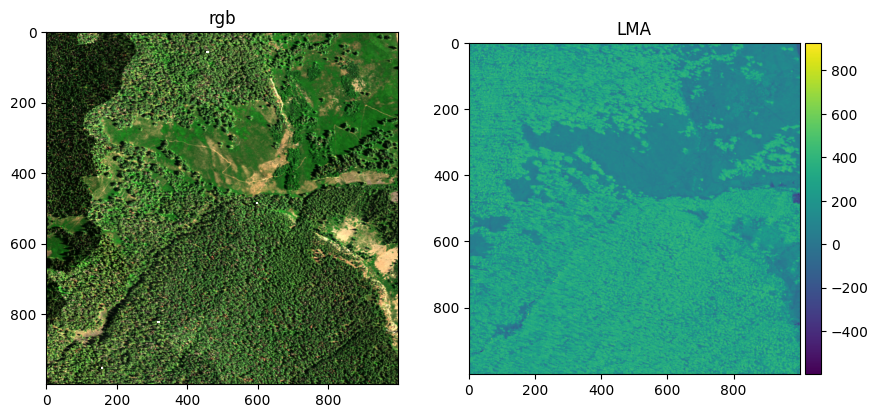

In [23]:
# visualize outputs

fig, axs = plt.subplots(1, 2, figsize=(10,5))

rgb = np.moveaxis(ds['reflectance'][[58,34,19], :, :].values, 0, -1)
axs[0].imshow(rgb/np.nanmax(rgb)*2)
axs[0].set_title('rgb')

p1 = axs[1].imshow(pred_img)
axs[1].set_title('LMA')

divider = make_axes_locatable(axs[1])
cax = divider.append_axes('right', size='5%', pad=0.05)

fig.colorbar(p1, cax=cax)
plt.show()